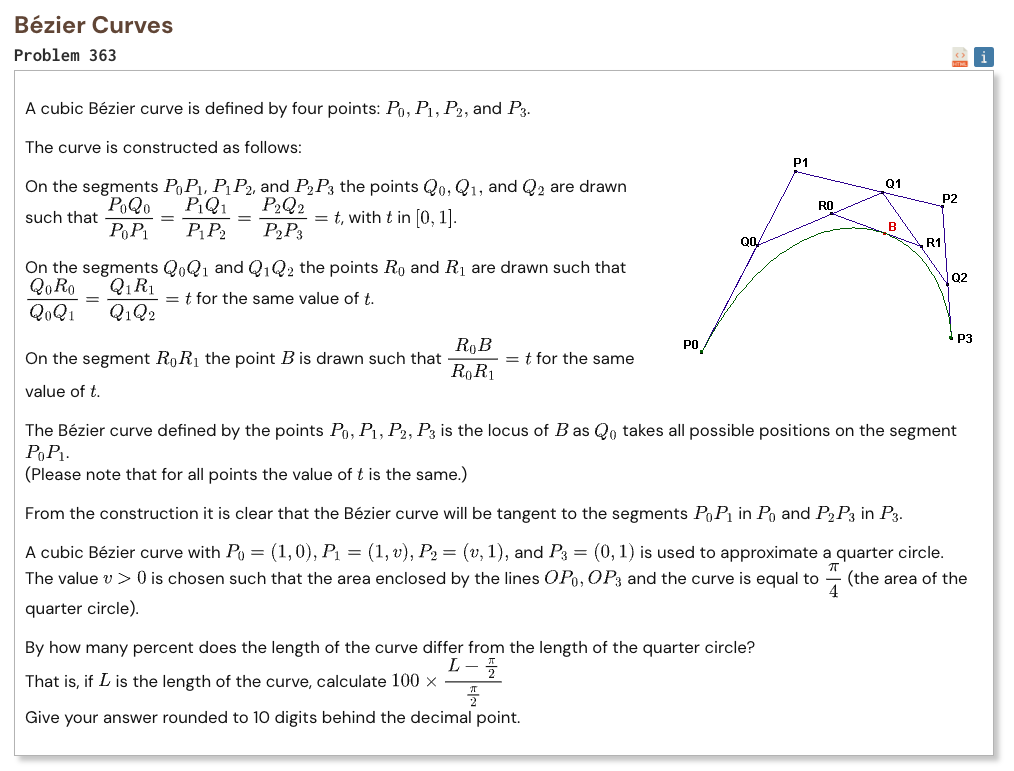

## Initial approach

* build the cubic bezier curve from the four control points
* use one unknown control distance to shape the curve
* choose that value so the enclosed area matches the quarter circle area
* find the value by binary search
* compute the curve length with numerical integration
* compare it with the quarter circle length
* print the percent difference rounded to ten digits

In [1]:
import math

def bezier_xy(t, v):
    u = 1 - t

    x = u ** 3 + 3 * u ** 2 * t + 3 * u * t ** 2 * v
    y = 3 * u ** 2 * t * v + 3 * u * t ** 2 + t ** 3

    return x, y

def bezier_derivatives(t, v):
    u = 1 - t

    dx = 3 * u ** 2 * (1 - 1) + 6 * u * t * (v - 1) + 3 * t ** 2 * (0 - v)
    dy = 3 * u ** 2 * v + 6 * u * t * (1 - v) + 3 * t ** 2 * (1 - 1)

    return dx, dy

def simpson_integral(func, v, steps=20000):
    h = 1 / steps
    total = func(0, v) + func(1, v)

    for i in range(1, steps):
        weight = 4 if i % 2 else 2
        total += weight * func(i * h, v)

    return total * h / 3

def area_integrand(t, v):
    x, y = bezier_xy(t, v)
    dx, dy = bezier_derivatives(t, v)
    return x * dy

def length_integrand(t, v):
    dx, dy = bezier_derivatives(t, v)
    return math.hypot(dx, dy)

def bezier_area(v):
    return simpson_integral(area_integrand, v)

def bezier_length(v):
    return simpson_integral(length_integrand, v)

def solve():
    target_area = math.pi / 4

    lo = 0.0
    hi = 1.0

    for _ in range(80):
        mid = (lo + hi) / 2

        if bezier_area(mid) < target_area:
            lo = mid
        else:
            hi = mid

    v = (lo + hi) / 2
    length = bezier_length(v)
    quarter_circle_length = math.pi / 2

    result = 100 * (length - quarter_circle_length) / quarter_circle_length
    return result

In [2]:
%%time
result = solve()
print("Result:", f"{result:.10f}")

Result: 0.0000372091
CPU times: user 1.42 s, sys: 6.65 ms, total: 1.43 s
Wall time: 1.43 s
